# Step 3: Geo-intervention Generation

## Libaries

In [2]:
from pathlib import Path
from pickle import dump, load
from pprint import pprint

import modules as geoint
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

/Users/rrwen/Desktop/geointerv-paper/tmp/venv/lib/python3.9/site-packages/geopandas/_compat.py:123: UserWarning: The Shapely GEOS version (3.11.1-CAPI-1.17.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(
/Users/rrwen/Desktop/geointerv-paper/src/case-study/modules/data.py:1: UserWarning: Shapely 2.0 is installed, but because PyGEOS is also installed, GeoPandas will still use PyGEOS by default for now. To force to use and test Shapely 2.0, you have to set the environment variable USE_PYGEOS=0. You can do this before starting the Python process, or in your code before importing geopandas:

import os
os.environ['USE_PYGEOS'] = '0'
import geopandas

In a future release, GeoPandas will switch to using Shapely by default. If you are using PyGEOS directly (calling PyGEOS functions on geometries from GeoPandas), this will then stop working and you are encouraged to migrate from PyGEOS to Shapely 2.0 

## Folders

Create folders for storing models and related data.

In [3]:
# Set folder for data and models
data_folder = '../../tmp/data'
model_folder = '../../tmp/models'
downloads_folder = '../../tmp/downloads'

# Create folders for model data
Path(data_folder).mkdir(parents=True, exist_ok=True)
Path(model_folder).mkdir(parents=True, exist_ok=True)

## Load Best Model

In [ ]:
# Load toronto boundaries for clipping
city = gpd.read_file(f'{downloads_folder}/toronto.geojson')\
    .to_crs(32617)

# Determine best model
scores = pd.read_csv(f'{model_folder}/scores.csv')
opt_model = scores[(scores.metric == 'mean_absolute_error')]\
    .sort_values('score')\
    .iloc[0]\
    .model
opt_model_label = opt_model\
    .replace('_10', ' (10x10)')\
    .replace('_40', ' (40x40)')\
    .replace('_80', ' (80x80)')

# Create dict for best model
models = {}
geodata = {}

# Determine size and model type based on name
model_type = opt_model.split('_')[0]
size = int(opt_model.split('_')[1])
    
# Load data
print(f'Processing geogrid_to_{size}...')
xraw = gpd.read_file(f'{data_folder}/geogrid_to_{size}.geojson')

# Clip data
xraw = xraw.clip(city)

# Drop geometry and set outcome var
x = pd.DataFrame(xraw.drop(columns='geometry'))
ycol = 'collisions_count'
ycol_label = 'Collision Counts'
geodata[f'geogrid_to_{size}'] = xraw
    
# Columns to remove from input data
startswith = ['collisions']

# Drop columns except target col
drop = [c for c in x.columns if any(c.startswith(s) for s in startswith) and c != ycol]
x = x.drop(columns=drop)
    
# Load autosklearn model
if model_type == 'autosklearn':
    ask_file = f'{model_folder}/autosklearn_{size}.pkl'
    print(f'Loading autosklearn_{size}...')
    with open(ask_file, 'rb') as f:
        ask = load(f)
    models[opt_model] = ask
    
# Load tpot model
if model_type == 'tpot':
    tpt_file = f'{model_folder}/tpot_{size}.pkl'
    print(f'Loading tpot_{size}...')
    tpt = geoint.models.AutoMLModel('TPOTRegressor')
    with open(tpt_file, 'rb') as f:
        tpt.model = load(f)
    tpt.last_x = x.drop(columns=ycol).select_dtypes('number').fillna(0)
    tpt.last_y = x[ycol]
    tpt.predict()
    models[opt_model] = tpt

print('Done!')

Processing geogrid_to_80...
Loading autosklearn_80...
Done!


## Optimization

In [5]:
# Determine top three infra vars
importances = pd.read_csv(f'{model_folder}/importances.csv')
importances_vars = importances[~importances.variable.str.startswith(('traffic', 'centrelines', 'crime'))]\
    .sort_values('importance_mean', ascending = False)\
    .head(3)\
    .variable\
    .tolist()

# Set top three infra var names
importances_names = [
    'Red Light Camera Counts',
    'Transit Shelter Counts',
    'Wayfinding Structure Counts'
]

# Determine top traffic var
importances_traffic = importances[
    importances.variable.str.startswith(('traffic')) &
    importances.variable.str.endswith(('sum'))
]\
    .sort_values('importance_mean', ascending = False)\
    .head(1)\
    .variable\
    .tolist()[0]

# Create dict for storing opt results
opt_results = {
    'scenario': [],
    'original': [],
    'optimized': [],
    'model': []
}

# Display traffic and infra vars
print(f'''
Traffic Variable
----------------
{importances_traffic}
      
Top Three Infrastructure Variables
----------------------------------
1. {importances_vars[0]}
2. {importances_vars[1]}
3. {importances_vars[2]}
''')


Traffic Variable
----------------
traffic_eb_cars_l_sum
      
Top Three Infrastructure Variables
----------------------------------
1. red_light_cams_count
2. transit_shelters_count
3. wayfind_count



### Scenario 1

Create geo-interventions by optimizing top three infrastructure variables with higher than average traffic.

In [6]:
# Define local constraints
query_traffic = {'query': f'{importances_traffic} >= {importances_traffic}.mean()'}
lconstr1 = {}
lconstr1[importances_vars[0]] = query_traffic
lconstr1[importances_vars[1]] = query_traffic
lconstr1[importances_vars[2]] = query_traffic

# Create optimizer
print(f'Optimizing predictions for {opt_model}...')
opt1_file = f'{model_folder}/{opt_model}_opt1.pkl'
opt1_max_file = f'{model_folder}/{opt_model}_opt1_max.pkl'
opt1_res_file = f'{model_folder}/{opt_model}_opt1_res.pkl'
if Path(opt1_file).is_file():
    
    # Load optimizer from saved file
    print(f'Optimizer for {opt_model} exists - loading results...')
    with open(opt1_file, 'rb') as f:
        opt1_results = load(f)

    # Load detailed opt results
    with open(opt1_max_file, 'rb') as f:
        opt1_max = load(f)
    with open(opt1_res_file, 'rb') as f:
        opt1_res = load(f)

else:
    
    # Run optimizer
    print(f'Running optimization for {opt_model}...')
    opt1 = geoint.optimization.Optimizer(models[opt_model], lconstr1, 'BayesianOptimization', verbose=0, ymax=False)
    opt1.optimize(n_iter=1000, init_points = 100)
    
    # Save results
    print(f'Saving optimization for {opt_model}...')
    opt1_results = {
        'original': [sum(opt1.model.last_y)],
        'optimized': [opt1.optimal_y],
        'optimal': opt1.optimal,
        'optimal_params': opt1.optimal_params,
        'optimal_details': opt1.optimal_details,
        'params': opt1.optimizer_params
    }
    with open(opt1_file, 'wb') as f:
        dump(opt1_results, f)

    # Save detailed results
    with open(opt1_max_file, 'wb') as fp:
        dump(opt1.optimizer.max, fp)
    with open(opt1_res_file, 'wb') as fp:
        dump(opt1.optimizer.res, fp)

        
# Store opt results
opt_results['scenario'] += ['Scenario 1: Higher than avg traffic']
opt_results['original'] += opt1_results['original']
opt_results['optimized'] += opt1_results['optimized']
opt_results['model'] += [opt_model]
print('Done!')

Optimizing predictions for autosklearn_80...
Optimizer for autosklearn_80 exists - loading results...
Done!


In [7]:
# Display s1 results
print(f'''
Scenario 1 Results
------------------
Original: {opt1_results['original'][0]}
Optimized: {opt1_results['optimized'][0]}
Difference: {opt1_results['optimized'][0] - opt1_results['original'][0]}
''')


Scenario 1 Results
------------------
Original: 588876.0
Optimized: 554583.9881602526
Difference: -34292.01183974743



### Scenario 2

Create geo-interventions by optimizing  top three infrastructure variables with lower than average numbers.

In [8]:
# Define local constraints
lconstr2 = {}
lconstr2[importances_vars[0]] = {'query': f'{importances_vars[0]} < {importances_vars[0]}.mean()'}
lconstr2[importances_vars[1]] = {'query': f'{importances_vars[1]} < {importances_vars[1]}.mean()'}
lconstr2[importances_vars[2]] = {'query': f'{importances_vars[2]} < {importances_vars[2]}.mean()'}

# Create optimizer
print(f'Optimizing predictions for {opt_model}...')
opt2_file = f'{model_folder}/{opt_model}_opt2.pkl'
opt2_max_file = f'{model_folder}/{opt_model}_opt2_max.pkl'
opt2_res_file = f'{model_folder}/{opt_model}_opt2_res.pkl'
if Path(opt2_file).is_file():
    
    # Load optimizer from saved file
    print(f'Optimizer for {opt_model} exists - loading results...')
    with open(opt2_file, 'rb') as f:
        opt2_results = load(f)

    # Load detailed opt results
    with open(opt2_max_file, 'rb') as f:
        opt2_max = load(f)
    with open(opt2_res_file, 'rb') as f:
        opt2_res = load(f)

else:
    
    # Run optimizer
    print(f'Running optimization for {opt_model}...')
    opt2 = geoint.optimization.Optimizer(models[opt_model], lconstr2, 'BayesianOptimization', verbose=0, ymax=False)
    opt2.optimize(n_iter=1000, init_points=100)
    
    # Save results
    print(f'Saving optimization for {opt_model}...')
    opt2_results = {
        'original': [sum(opt2.model.last_y)],
        'optimized': [opt2.optimal_y],
        'optimal': opt2.optimal,
        'optimal_params': opt2.optimal_params,
        'optimal_details': opt2.optimal_details,
        'params': opt2.optimizer_params
    }
    with open(opt2_file, 'wb') as f:
        dump(opt2_results, f)

    # Save detailed results
    with open(opt2_max_file, 'wb') as fp:
        dump(opt2.optimizer.max, fp)
    with open(opt2_res_file, 'wb') as fp:
        dump(opt2.optimizer.res, fp)
        
# Store opt results
opt_results['scenario'] += ['Scenario 2: Modify scarce intervention cells']
opt_results['original'] += opt2_results['original']
opt_results['optimized'] += opt2_results['optimized']
opt_results['model'] += [opt_model]
print('Done!')

Optimizing predictions for autosklearn_80...
Optimizer for autosklearn_80 exists - loading results...
Done!


In [9]:
# Display s2 results
print(f'''
Scenario 2 Results
------------------
Original: {opt2_results['original'][0]}
Optimized: {opt2_results['optimized'][0]}
Difference: {opt2_results['optimized'][0] - opt2_results['original'][0]}
''')


Scenario 2 Results
------------------
Original: 588876.0
Optimized: 575680.5215597171
Difference: -13195.478440282866



### Optimization Results

In [10]:
opt_results = pd.DataFrame(opt_results)
opt_results['diff'] = opt_results.optimized - opt_results.original
opt_results

,scenario,original,optimized,model,diff
0,Scenario 1: Higher than avg traffic,588876.0,554583.98816,autosklearn_80,-34292.01184
1,Scenario 2: Modify scarce intervention cells,588876.0,575680.52156,autosklearn_80,-13195.47844


## Generated Geo-interventions

In [11]:
# Read data for selected model
gdata = geodata[f'geogrid_to_{size}'].copy()
gcols = importances_vars

# Get optimal parameters
optimalp = {
    'opt1': opt1_results['optimal_params'],
    'opt2': opt2_results['optimal_params'],
}

# Get params used for optimization
opt_params = {
    'opt1': opt1_results['params'],
    'opt2': opt2_results['params']
}
for k in opt_params:
    opt_params[k].index.name = None
    
# Set params to optimal params
for k in opt_params:
    opt_params[k]['value_optimal'] = opt_params[k]['value_orig']
    opt_params[k].loc[optimalp[k].keys(), 'value_optimal'] = list(optimalp[k].values())

In [12]:
# Set data to optimal params
for k in opt_params:
    params = opt_params[k]
    for c in params.column.unique():
        p = params[params.column == c]
        oc = f'{c}_{k}'
        gdata[oc] = gdata[c].copy()
        gdata.loc[p.row, oc] = p.value_optimal.tolist()
        gdata[f'{oc}_diff'] = gdata[oc] - gdata[c]

In [13]:
gdata[[c + '_opt1' for c in gcols] + [c + '_opt2' for c in gcols] + [ycol]].head(100)

,red_light_cams_count_opt1,transit_shelters_count_opt1,wayfind_count_opt1,red_light_cams_count_opt2,transit_shelters_count_opt2,wayfind_count_opt2,collisions_count
2446,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2447,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2569,0.0,0.0,0.0,0.0,0.0,0.0,2.0
2508,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2509,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...
1662,0.0,2.0,3.0,0.0,2.0,3.0,286.0
1541,0.0,6.0,0.0,0.0,6.0,0.0,188.0
1724,0.0,1.0,0.0,0.0,1.0,0.0,220.0
1663,0.0,4.0,0.0,0.0,4.0,0.0,164.0


### Optimization Parameters

In [14]:
opt_params['opt1'].head(100)

,column,row,param,value,bounds,value_orig,value_optimal
red_light_cams_count_1533,red_light_cams_count,1533,red_light_cams_count_1533,0.857207,"(0.0, 4.0)",1.0,0.0
red_light_cams_count_1595,red_light_cams_count,1595,red_light_cams_count_1595,0.118614,"(0.0, 4.0)",0.0,0.0
red_light_cams_count_1534,red_light_cams_count,1534,red_light_cams_count_1534,1.302403,"(0.0, 4.0)",0.0,0.0
red_light_cams_count_1474,red_light_cams_count,1474,red_light_cams_count_1474,1.834289,"(0.0, 4.0)",0.0,0.0
red_light_cams_count_1658,red_light_cams_count,1658,red_light_cams_count_1658,0.868784,"(0.0, 4.0)",1.0,0.0
...,...,...,...,...,...,...,...
red_light_cams_count_2094,red_light_cams_count,2094,red_light_cams_count_2094,2.398417,"(0.0, 4.0)",0.0,0.0
red_light_cams_count_2155,red_light_cams_count,2155,red_light_cams_count_2155,1.000751,"(0.0, 4.0)",1.0,0.0
red_light_cams_count_2156,red_light_cams_count,2156,red_light_cams_count_2156,2.633786,"(0.0, 4.0)",1.0,0.0
red_light_cams_count_1973,red_light_cams_count,1973,red_light_cams_count_1973,2.055985,"(0.0, 4.0)",0.0,0.0


In [15]:
len(opt_params['opt1'].index)

1443

In [16]:
opt_params['opt2'].head(100)

,column,row,param,value,bounds,value_orig,value_optimal
red_light_cams_count_2446,red_light_cams_count,2446,red_light_cams_count_2446,1.603507,"(0.0, 4.0)",0.0,0.0
red_light_cams_count_2447,red_light_cams_count,2447,red_light_cams_count_2447,1.110811,"(0.0, 4.0)",0.0,0.0
red_light_cams_count_2569,red_light_cams_count,2569,red_light_cams_count_2569,0.104405,"(0.0, 4.0)",0.0,0.0
red_light_cams_count_2508,red_light_cams_count,2508,red_light_cams_count_2508,1.533748,"(0.0, 4.0)",0.0,0.0
red_light_cams_count_2509,red_light_cams_count,2509,red_light_cams_count_2509,0.977393,"(0.0, 4.0)",0.0,0.0
...,...,...,...,...,...,...,...
red_light_cams_count_1602,red_light_cams_count,1602,red_light_cams_count_1602,2.705350,"(0.0, 4.0)",0.0,0.0
red_light_cams_count_1725,red_light_cams_count,1725,red_light_cams_count_1725,3.347151,"(0.0, 4.0)",0.0,0.0
red_light_cams_count_1664,red_light_cams_count,1664,red_light_cams_count_1664,0.876445,"(0.0, 4.0)",0.0,0.0
red_light_cams_count_1542,red_light_cams_count,1542,red_light_cams_count_1542,0.853372,"(0.0, 4.0)",0.0,0.0


In [17]:
len(opt_params['opt2'].index)

6131

### Optimization Iterations

Scenario 1.

Text(583, 564583.9881602526, 'Optimal Iteration: 983\nOptimal MVC: 554584\nInitial MVC: 588190\nDifference: -33606')

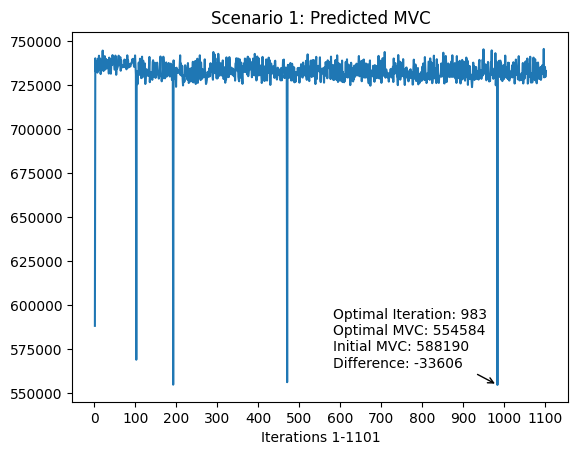

In [19]:
# Get iteration data
opt1_iter = pd.DataFrame({
    'MVC': [i['target'] * -1 for i in opt1_res],
    'Iteration': range(1, len(opt1_res) + 1)
})

# Get optimal iteration value
opt1_iter_pred = opt1_res[0]['target'] * -1
opt1_iter_opt = opt1_iter[opt1_iter.MVC == opt1_iter.MVC.min()]
opt1_iter_i = opt1_iter_opt.Iteration.to_list()[0]
opt1_iter_y = opt1_iter_opt.MVC.to_list()[0]
opt1_iter_diff = opt1_iter_y - opt1_iter_pred

# Plot iterations
opt1_iter.plot(
    x = 'Iteration',
    xlabel = 'Iterations 1-1101',
    title = 'Scenario 1: Predicted MVC',
    legend = False,
    xticks = np.arange(0, 1101, 100)
).annotate(
    f'Optimal Iteration: {opt1_iter_i}\n'
    f'Optimal MVC: {opt1_iter_y:.0f}\n'
    f'Initial MVC: {opt1_iter_pred:.0f}\n'
    f'Difference: {opt1_iter_diff:.0f}', 
    xy=(opt1_iter_i, opt1_iter_y),
    xytext=(opt1_iter_i - 400, opt1_iter_y + 10000),
    arrowprops=dict(arrowstyle="->"),  # Arrow style
    fontsize=10
)

Scenario 2.

Text(101, 595680.5215597171, 'Optimal Iteration: 1\nOptimal MVC: 575681\nInitial MVC: 575681\nDifference: 0')

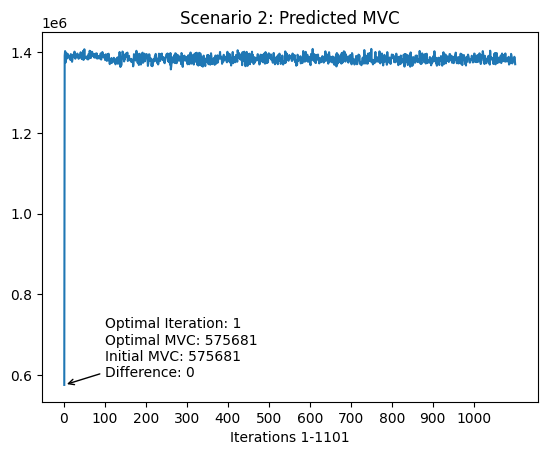

In [28]:
# Get iteration data
opt2_iter = pd.DataFrame({
    'MVC': [i['target'] * -1 for i in opt2_res],
    'Iteration': range(1, len(opt2_res) + 1)
})

# Get optimal iteration value
opt2_iter_pred = opt2_res[0]['target'] * -1
opt2_iter_opt = opt2_iter[opt2_iter.MVC == opt2_iter.MVC.min()]
opt2_iter_i = opt2_iter_opt.Iteration.to_list()[0]
opt2_iter_y = opt2_iter_opt.MVC.to_list()[0]
opt2_iter_diff = opt2_iter_y - opt2_iter_pred

# Plot iterations
opt2_iter.plot(
    x = 'Iteration',
    xlabel = 'Iterations 1-1101',
    title = 'Scenario 2: Predicted MVC',
    legend = False,
    xticks = np.arange(0, 1001, 100)
).annotate(
    f'Optimal Iteration: {opt2_iter_i}\n'
    f'Optimal MVC: {opt2_iter_y:.0f}\n'
    f'Initial MVC: {opt2_iter_pred:.0f}\n'
    f'Difference: {opt2_iter_diff:.0f}', 
    xy=(opt2_iter_i, opt2_iter_y),
    xytext=(opt2_iter_i + 100, opt2_iter_y + 20000),
    arrowprops=dict(arrowstyle="->"),  # Arrow style
    fontsize=10
)

### Geo-intervention Parameters

Correlations.

In [22]:
gcorr = geodata['geogrid_to_80'].corr()

/var/folders/lg/1tfppccd38s1sn9w5z9g_mcm0000gn/T/ipykernel_2861/3223531731.py:1: FutureWarning: The default value of numeric_only in GeoDataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  gcorr = geodata['geogrid_to_80'].corr()


In [23]:
# Get correlations for top 3 vars
gcorr1 = gcorr[importances_vars[0]]
gcorr2 = gcorr[importances_vars[1]]
gcorr3 = gcorr[importances_vars[2]]

# Find high correlations
gcorr_df = {'column': [], 'column_corr': [], 'corr': []}
for c in importances_vars:
    gc = gcorr[c]
    hicorr = gc[(gc > 0.6) | (gc < -0.6)]
    gcorr_df['column'] += [c] * len(hicorr)
    gcorr_df['column_corr'] += hicorr.index.to_list()
    gcorr_df['corr'] += hicorr.to_list()

# Construct high correlation df
gcorr_df = pd.DataFrame(gcorr_df)
gcorr_df = gcorr_df[gcorr_df.column != gcorr_df.column_corr]

# Save correlations
gcorr_df = gcorr_df.sort_values(by = ['column', 'corr'], ascending = False)
gcorr_df.to_csv(f'{model_folder}/hicorr.csv')

Scenario 1.

In [24]:
gdata[[c + '_opt1_diff' for c in importances_vars]].sum()


red_light_cams_count_opt1_diff      -165.266525
transit_shelters_count_opt1_diff   -1915.965522
wayfind_count_opt1_diff             -100.094060
dtype: float64

Scenario 2.

In [25]:
gdata[[c + '_opt2_diff' for c in importances_vars]].sum()

red_light_cams_count_opt2_diff      0.0
transit_shelters_count_opt2_diff    0.0
wayfind_count_opt2_diff             0.0
dtype: float64

### Geo-intervention Maps

Scenario 1

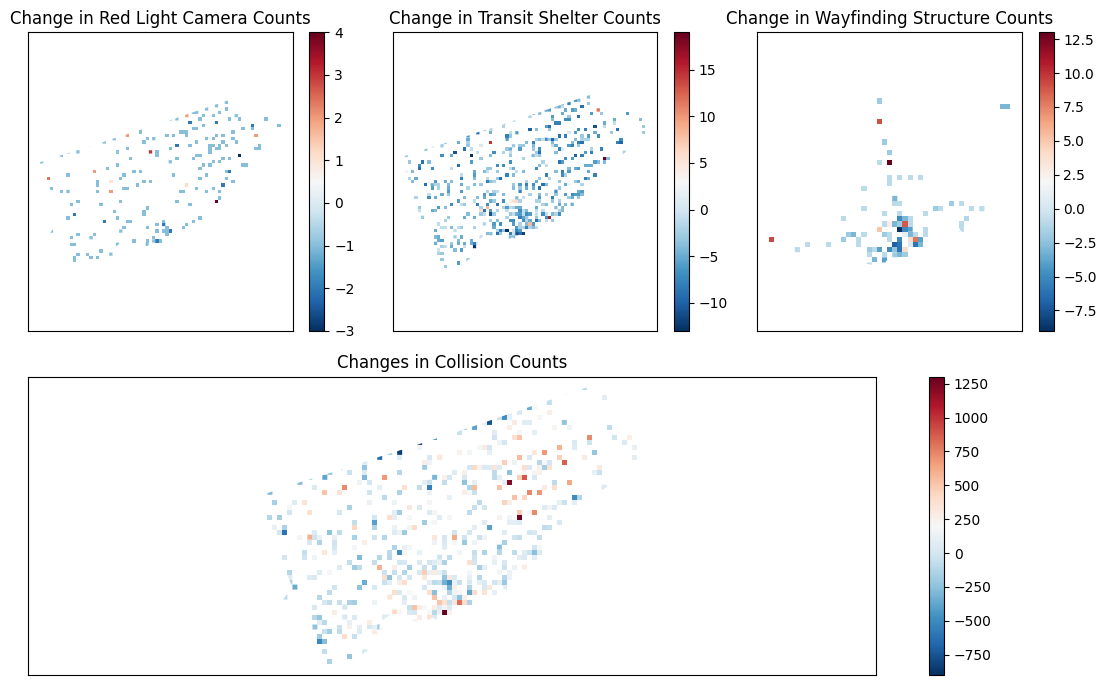

In [94]:
#fig = plt.figure()
#fig.set_size_inches(11, 3)

# Format plot data
pdata = gdata.copy()
pdata.replace(0, np.nan, inplace=True)

# Setup plot grid
fig = plt.figure(figsize=(11, 7))
gs = fig.add_gridspec(2, 3, height_ratios=[1, 1], width_ratios=[1, 1, 1])

# S1 infra 1
ax1 = fig.add_subplot(gs[0, 0])
pdata.plot(ax=ax1, cmap='RdBu_r', column=f'{importances_vars[0]}_opt1_diff', legend=True)
ax1.set_title(f'Change in {importances_names[0]}')
ax1.set_aspect('equal', adjustable='datalim')
ax1.axes.get_xaxis().set_visible(False)
ax1.axes.get_yaxis().set_visible(False)

# S1 infra 2
ax2 = fig.add_subplot(gs[0, 1])
pdata.plot(ax=ax2, cmap='RdBu_r', column=f'{importances_vars[1]}_opt1_diff', legend=True)
ax2.set_title(f'Change in {importances_names[1]}')
ax2.set_aspect('equal', adjustable='datalim')
ax2.axes.get_xaxis().set_visible(False)
ax2.axes.get_yaxis().set_visible(False)

# S1 infra 3
ax3 = fig.add_subplot(gs[0, 2])
pdata.plot(ax=ax3, cmap='RdBu_r', column=f'{importances_vars[2]}_opt1_diff', legend=True)
ax3.set_title(f'Change in {importances_names[2]}')
ax3.set_aspect('equal', adjustable='datalim')
ax3.axes.get_xaxis().set_visible(False)
ax3.axes.get_yaxis().set_visible(False)

# Replace original values with optimal values
s1data = gdata.copy()
for c in importances_vars:
    s1data[c] = s1data[f'{c}_opt1']

# Get predictions for opt scenarios
pcols = models[opt_model].last_x.columns
s1pred = models[opt_model].predict(s1data[pcols])
opred = models[opt_model].predict(xraw[pcols])

# Add col for opt pred scenarios
s1data[ycol + '_opt1'] = s1pred
s1data[ycol + '_pred'] = opred

# Calc diff between orig and opt scenarios
s1data[ycol + '_opt1_diff'] = s1data[ycol] - s1data[ycol + '_opt1']

# Reduced collisions
ax4 = fig.add_subplot(gs[1, :])
s1data = s1data[
    s1data[importances_traffic] >= s1data[importances_traffic].mean()
]
s1data[f'{ycol}_opt1_diff'] = s1data[f'{ycol}_opt1_diff']\
    .replace(0, np.nan)
s1data.plot(ax=ax4, cmap='RdBu_r', column=f'{ycol}_opt1_diff', legend=True)
ax4.set_title(f'Changes in {ycol_label}')
ax4.set_aspect('equal', adjustable='datalim')
ax4.axes.get_xaxis().set_visible(False)
ax4.axes.get_yaxis().set_visible(False)

plt.tight_layout()
plt.show()

No changes in Scenario 2.